In [5]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
import csv
import os

In [6]:
gwas = pd.read_csv('/machineLearningForComputationalBiology/gwasEnrichments/gwas/unmunged_sumstats/Alzheimers_GWAS/Bellenguez2022_GCST90027158_buildGRCh38.tsv.gz',
                  sep = '\t')
gwas['-log10 p-value'] = -np.log10(gwas['p_value'])
plotdir = '/Aging/LQ_TACIT/plots'

/home/gabdelha/miniconda3/envs/SingleCell_Env/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


pos
L2.3.IT
L4.5.IT
L5.6.IT.Car3
L5.6.NP
L5.ET
L6.CT
L6.IT
LAMP5
PAX6
PVALB
SST
VIP
Astro
Microglia
Oligo
Opc
Endo
neg
L2.3.IT
L4.5.IT
L5.6.IT.Car3
L5.6.NP
L5.ET
L6.CT
L6.IT
LAMP5
PAX6
PVALB
SST
VIP
Astro
Microglia
Oligo
Opc
Endo


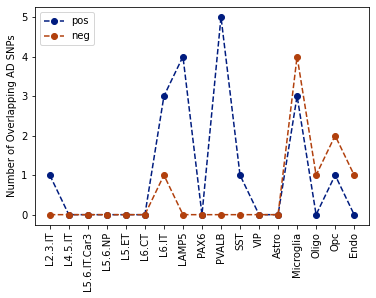

In [10]:
# Manuscript Supp Figure 2 --------------------------------------------------------
#----------------------------------------------------------------------------------

# Enhancers

OUT_DIR = '/Aging/LQ_TACIT/gwas/'
celltypes = ['L2.3.IT','L4.5.IT','L5.6.IT.Car3','L5.6.NP','L5.ET','L6.CT','L6.IT',
             'LAMP5', 'PAX6','PVALB','SST','VIP','Astro','Microglia','Oligo','Opc','Endo']
directn = ['pos', 'neg']

df2 = pd.DataFrame()
for d in range(len(directn)):
    print(directn[d])
    df1 = pd.DataFrame()
    for c in range(len(celltypes)):
        print(celltypes[c])
        file_path = str(OUT_DIR)+str(celltypes[c])+'_r0_'+str(directn[d])+'_enhancer_Bellenguez_intersect.txt'
        if os.stat(file_path).st_size == 0:
            snp = pd.DataFrame()
        else:
            snp = pd.read_csv(file_path, sep = '\t', header = None)
        n = snp.shape[0]
        df = pd.DataFrame(data =[n], index = [celltypes[c]], columns = [directn[d]])
        df1 = pd.concat([df1, df], axis=0)
    df2 = pd.concat([df2, df1], axis=1)

color = ['#001C7F','#B1400D']
for i, col in enumerate(df2.columns):
    plt.plot(df2.index, df2[col], 'o--', label=col, color=color[i])
plt.xticks(rotation=90)
plt.ylabel('Number of Overlapping AD SNPs')
plt.legend(loc="upper left")

OUT_DIR = '/Aging/LQ_TACIT/plots/'
#plt.savefig(str(OUT_DIR)+'hg38_AD_Bellenguez_intersect_enhancers.pdf')

Window: chr2:127,028,032-127,240,299 (212,267 bp)

Highlighted SNPs (4):
variant_id  base_pair_location  -log10 p-value            p
rs13025717           127128582       28.755723 1.755000e-29
rs13025765           127128657       28.746904 1.791000e-29
rs12618593           127128795       28.724689 1.885000e-29
rs12617835           127128840       28.739452 1.822000e-29


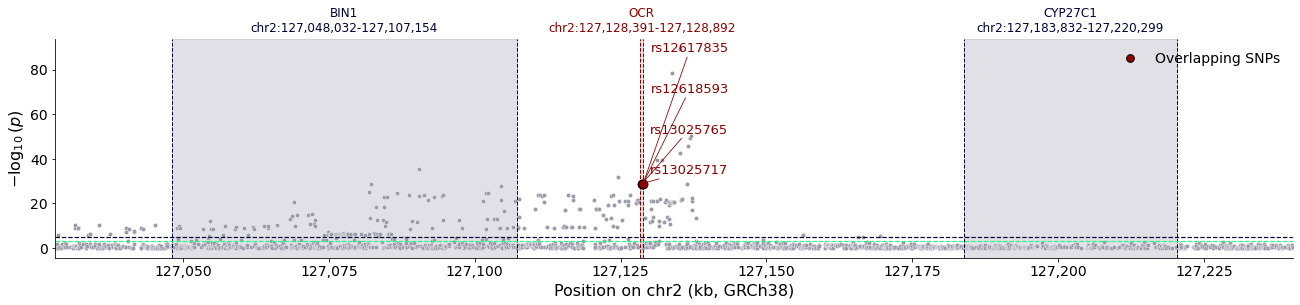

In [24]:
# Manuscript Supp Figure 3 --------------------------------------------------------
#----------------------------------------------------------------------------------

# ----------------------------------------------------------------------
# Typography. Change FONT only -- everything else scales off it.
# ----------------------------------------------------------------------
FONT = 14
plt.rcParams.update({
    'font.size':       FONT,
    'axes.labelsize':  FONT + 2,
    'axes.titlesize':  FONT + 2,
    'xtick.labelsize': FONT,
    'ytick.labelsize': FONT,
    'legend.fontsize': FONT,
})

# ----------------------------------------------------------------------
# Locus definitions. Chromosome, genes and SNPs live together so they
# can't drift out of sync (that was the original bug).
# ----------------------------------------------------------------------
LOCI = {
    'BIN1': {
        'chromosome': 2,
        'regions': [
            {'name': 'BIN1',    'start': 127_048_032, 'end': 127_107_154},
            {'name': 'OCR',     'start': 127_128_391, 'end': 127_128_892},
            {'name': 'CYP27C1', 'start': 127_183_832, 'end': 127_220_299},
        ],
        'snps': [
            'rs12617835',
            'rs12618593',
            'rs13025765',
            'rs13025717',
        ],
    },
    'FERMT2': {
        'chromosome': 14,
        'regions': [
            {'name': 'GNPNAT1', 'start': 52_775_193, 'end': 52_791_607},
            {'name': 'OCR',     'start': 52_844_599, 'end': 52_845_100},
            {'name': 'FERMT2',  'start': 52_857_273, 'end': 52_951_050},
        ],
        'snps': ['rs12588482', 'rs7160285'],
    },
}

LOCUS_NAME = 'BIN1'          # <-- switch to 'FERMT2' for the chr14 locus
LOCUS = LOCI[LOCUS_NAME]
CHROM = LOCUS['chromosome']

# Window: derived from the regions with PAD bp of flank, unless WINDOW is
# set explicitly. Deriving it means it can never disagree with the regions.
PAD = 20_000
WINDOW = None                # e.g. (127_123_000, 127_134_000) to force it

if WINDOW is not None:
    WIN_START, WIN_END = WINDOW
else:
    WIN_START = min(r['start'] for r in LOCUS['regions']) - PAD
    WIN_END   = max(r['end']   for r in LOCUS['regions']) + PAD

print(f'Window: chr{CHROM}:{WIN_START:,}-{WIN_END:,} '
      f'({WIN_END - WIN_START:,} bp)')

SUGGESTIVE = 1e-3
GENOMEWIDE = 1e-5

# ----------------------------------------------------------------------
# Would the window drop any of the labelled SNPs?
# ----------------------------------------------------------------------
_pos = gwas.loc[gwas['variant_id'].isin(LOCUS['snps']), 'base_pair_location']
_out = _pos[(_pos < WIN_START) | (_pos > WIN_END)]
if not _out.empty:
    print(f'WARNING: {len(_out)} labelled SNP(s) fall outside the window: '
          f'{sorted(_out)}')

# ----------------------------------------------------------------------
# Subset the GWAS
# ----------------------------------------------------------------------
gwas2 = (
    gwas[(gwas['chromosome'] == CHROM)
         & (gwas['base_pair_location'] >= WIN_START)
         & (gwas['base_pair_location'] <= WIN_END)]
    .sort_values('base_pair_location')
    .reset_index(drop=True)
)

if gwas2.empty:
    raise ValueError(
        f'No SNPs on chr{CHROM} between {WIN_START:,} and {WIN_END:,}. '
        'Check that the chromosome column is numeric and that the window '
        'matches the chromosome.'
    )

for region in LOCUS['regions']:
    if region['start'] > region['end']:
        print(f'WARNING: {region["name"]} has start > end -- likely a typo')

# ----------------------------------------------------------------------
# Extract the SNPs of interest
# ----------------------------------------------------------------------
snp = (gwas2[gwas2['variant_id'].isin(LOCUS['snps'])]
       .sort_values('base_pair_location'))

missing = set(LOCUS['snps']) - set(snp['variant_id'])
if missing:
    print(f'WARNING: not found in this window: {sorted(missing)}')

print(f'\nHighlighted SNPs ({len(snp)}):')
if not snp.empty:
    out = snp[['variant_id', 'base_pair_location', '-log10 p-value']].copy()
    out['p'] = 10 ** -out['-log10 p-value']
    print(out.to_string(index=False))

# ----------------------------------------------------------------------
# Plot
# ----------------------------------------------------------------------
plot = sns.relplot(
    data=gwas2, x='base_pair_location', y='-log10 p-value',
    aspect=3.7, height=5, color='#9a9aa8', s=18, legend=None,
)
ax = plot.ax
ax.set_xlim(WIN_START, WIN_END)
ax.set_ylabel(r'$-\log_{10}(p)$')

# Axis units follow the window size, so a tight zoom doesn't print the
# same Mb value on every tick.
if (WIN_END - WIN_START) >= 500_000:
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x / 1e6:.2f}'))
    ax.set_xlabel(f'Position on chr{CHROM} (Mb, GRCh38)')
else:
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x / 1e3:,.0f}'))
    ax.set_xlabel(f'Position on chr{CHROM} (kb, GRCh38)')

ax.axhline(y=-np.log10(GENOMEWIDE), linestyle='--', color='#000435', lw=1.2)
ax.axhline(y=-np.log10(SUGGESTIVE), linestyle='--', color='#21FE80', lw=1.2)

# Shade genes / regulatory regions. Plotting in bp means no index lookup,
# so a region containing zero SNPs still draws correctly.
region_colors = {'OCR': 'darkred'}
default_color = '#000435'
label_trans = ax.get_xaxis_transform()   # x in data coords, y in axes coords

for region in LOCUS['regions']:
    color = region_colors.get(region['name'], default_color)
    ax.axvspan(region['start'], region['end'], color=color, alpha=0.12, zorder=0)
    ax.axvline(region['start'], linestyle='--', color=color, lw=1.0, zorder=1)
    ax.axvline(region['end'], linestyle='--', color=color, lw=1.0, zorder=1)
    # Clip the label to the axes so a partly off-screen region stays legible
    mid = np.clip((region['start'] + region['end']) / 2, WIN_START, WIN_END)
    ax.text(
        mid, 1.02,
        f'{region["name"]}\nchr{CHROM}:{region["start"]:,}-{region["end"]:,}',
        transform=label_trans, ha='center', va='bottom',
        fontsize=FONT - 2, color=color, clip_on=False,
    )

# ----------------------------------------------------------------------
# Overplot the selected SNPs in red, at their own -log10 p
# ----------------------------------------------------------------------
ax.scatter(
    snp['base_pair_location'], snp['-log10 p-value'],
    s=80, color='darkred', edgecolor='black', linewidth=0.6, zorder=4,
)

# Label offsets are in points, so they track the font size.
for n, (_, row) in enumerate(snp.iterrows()):
    ax.annotate(
        f'{row["variant_id"]}',
        xy=(row['base_pair_location'], row['-log10 p-value']),
        xytext=(8, 10 + 2.9 * FONT * n), textcoords='offset points',
        fontsize=FONT - 1, color='darkred', zorder=5,
        arrowprops=dict(arrowstyle='-', color='darkred', lw=0.8,
                        shrinkA=0, shrinkB=3),
    )

ax.legend(
    handles=[Line2D([0], [0], marker='o', linestyle='', color='darkred',
                    markersize=FONT * 0.55, markeredgecolor='black',
                    label='Overlapping SNPs')],
    loc='upper right', frameon=False,
)

plot.figure.subplots_adjust(top=0.76)
plt.show()

#plot.savefig(
#     f'{plotdir}/AD_Bellenguez2022_GCST90027158_GRCh38_'
#    f'chr{CHROM}_{WIN_START}-{WIN_END}_v2.pdf',
#dpi=300, bbox_inches='tight',
#)